# Multi-Agent Code Generation: Coordination Collapse Study
## Main Experiment Notebook

**Pipeline:** Single-Agent Baseline | 2-Agent (Architect→Implementer) | 3-Agent (Architect→Implementer→Validator→Implementer)

The Validator is a **genuinely separate agent** with a distinct role:
- It receives the spec AND the code
- It identifies specific constraint violations
- It returns structured diagnostic feedback
- The Implementer receives this feedback and produces a corrected implementation

This is architecturally distinct from self-refinement (same model, no external diagnosis).


In [1]:
# =========================================================
# CELL 1: Install Dependencies
# =========================================================
!pip install -q transformers datasets accelerate \
    sentence-transformers scikit-learn pandas tqdm \
    scipy statsmodels matplotlib


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# =========================================================
# CELL 2: Imports, Device Setup, Reproducibility
# =========================================================
import torch, random, numpy as np, pandas as pd
import json, re, os, sys, subprocess, tempfile, textwrap, time
import warnings
warnings.filterwarnings("ignore")

from datasets import load_dataset
from tqdm import tqdm
from scipy.stats import bootstrap as scipy_bootstrap
from statsmodels.stats.contingency_tables import mcnemar
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams.update({"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
from transformers import AutoTokenizer, AutoModelForCausalLM

# ── Reproducibility ──────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}  |  Seed: {SEED}")

Device: cuda  |  Seed: 42


In [3]:
# =========================================================
# CELL 3: Load HumanEval Dataset (164 tasks)
# =========================================================
dataset = load_dataset("openai_humaneval")
data    = dataset["test"]
print(f"Total tasks: {len(data)}")

Total tasks: 164


In [4]:
# =========================================================
# CELL 4: Load Main Model (6.7B — Architect + Implementer)
# Loaded directly in 16-bit precision (no quantization).
# Requires a GPU server with 24GB+ VRAM.
# =========================================================
import torch

model_name = "deepseek-ai/deepseek-coder-6.7b-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print(f"Main model loaded natively in 16-bit: {model_name}\n")

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.56it/s]


Main model loaded natively in 16-bit: deepseek-ai/deepseek-coder-6.7b-instruct



In [5]:
# =========================================================
# CELL 4B: Validator Model
# All three roles (Architect, Implementer, Validator) now
# use the same 6.7B model. Reuse the objects from Cell 4.
# =========================================================

validator_model_name = model_name          # same: deepseek-6.7b
validator_tokenizer  = tokenizer           # reuse
validator_model      = model               # reuse

print(f"Validator reuses main model: {validator_model_name}")
print("All three agents now use DeepSeek-Coder 6.7B.")


Validator reuses main model: deepseek-ai/deepseek-coder-6.7b-instruct
All three agents now use DeepSeek-Coder 6.7B.


In [6]:
# =========================================================
# CELL 5: Generation Functions — Main + Validator (separate)
# All three agents use 6.7B (tokenizer/model = validator_tokenizer/validator_model).
# max_new_tokens: Architect=512, Implementer=384, Validator=256
# =========================================================

def generate(prompt, system_message="You are an expert Python programmer.",
             max_new_tokens=384):
    """Main generation — uses 6.7B model (Architect + Implementer)."""
    messages = [
        {"role": "system", "content": system_message},
        {"role": "user",   "content": prompt}
    ]
    try:
        formatted = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        formatted = f"{system_message}\n\n{prompt}"

    inputs = tokenizer(formatted, return_tensors="pt",
                       truncation=True, max_length=2048).to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    input_len = inputs["input_ids"].shape[1]
    return tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True).strip()


def generate_validator(prompt, max_new_tokens=256):
    """Validator generation — uses 6.7B model. 256 tokens sufficient for verdict."""
    system_message = "You are a strict Python code validator. Be precise and critical."
    messages = [
        {"role": "system", "content": system_message},
        {"role": "user",   "content": prompt}
    ]
    try:
        formatted = validator_tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        formatted = f"{system_message}\n\n{prompt}"

    inputs = validator_tokenizer(formatted, return_tensors="pt",
                                  truncation=True, max_length=2048).to(device)
    with torch.no_grad():
        outputs = validator_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=validator_tokenizer.eos_token_id
        )
    input_len = inputs["input_ids"].shape[1]
    return validator_tokenizer.decode(
        outputs[0][input_len:], skip_special_tokens=True).strip()

print("Generation functions defined.")


Generation functions defined.


In [7]:
# =========================================================
# CELL 6: Code Extraction (canonical)
# =========================================================

def extract_code(text):
    """Extract executable Python from model output.
    Priority: ```python block > bare def/import fallback.
    Strips prompt echo after '### Response:'.
    """
    if "### Response:" in text:
        text = text.split("### Response:")[-1]
    m = re.search(r"```python(.*?)```", text, re.DOTALL)
    if m:
        return m.group(1).strip()
    m = re.search(r"(import .*|from .*|def\s+\w+\(.*)", text, re.DOTALL)
    if m:
        return m.group(0).strip()
    return text.strip()

In [8]:
# =========================================================
# CELL 7: Safe Subprocess-Based Test Execution
# subprocess avoids fork-related hangs in Jupyter/Colab
# =========================================================

def run_test_safe(generated_code, test_code, entry_point, timeout=10):
    """Run generated code + HumanEval tests in isolated subprocess.
    Returns True iff all assertions pass within timeout seconds.
    """
    wrapper = textwrap.dedent(f"""
import sys
{generated_code}

def candidate(*args, **kwargs):
    return {entry_point}(*args, **kwargs)

{test_code}

check({entry_point})
""")
    with tempfile.NamedTemporaryFile(mode="w", suffix=".py", delete=False) as f:
        f.write(wrapper); fname = f.name
    try:
        result = subprocess.run([sys.executable, fname],
                                capture_output=True, timeout=timeout)
        return result.returncode == 0
    except subprocess.TimeoutExpired:
        return False
    except Exception:
        return False
    finally:
        os.unlink(fname)

In [9]:
# =========================================================
# CELL 8: Prompt Builders — Fixed Versions
# =========================================================

# ── Agent 0: Single-Agent Baseline ───────────────────────
def build_single_agent_prompt(task_prompt):
    return (
        "You are an expert Python programmer.\n\n"
        "Write a correct and efficient implementation for the following problem.\n\n"
        f"{task_prompt}\n\n"
        "Only output valid Python code. No explanation."
    )

# ── Agent 1: Architect — FIXED ───────────────────────────
# Key fixes:
# 1. Explicitly told to preserve ALL constraints from docstring
# 2. Told to copy examples exactly
# 3. Told what happens if spec is incomplete
def build_architect_prompt(task_prompt):
    return (
        "You are a software architect. Your job is to convert a Python "
        "function specification into a structured plain-text spec.\n\n"
        "CRITICAL RULES:\n"
        "- DO NOT write any Python code\n"
        "- DO NOT skip or summarize constraints — copy them ALL\n"
        "- DO NOT add constraints that are not in the original\n"
        "- If the docstring has examples, include them under EXAMPLES\n"
        "- If a constraint section would be empty, write NONE\n"
        "- An incomplete spec will cause the implementation to fail\n\n"
        "OUTPUT FORMAT — use this exactly:\n\n"
        "FUNCTION SIGNATURE:\n"
        "<copy the exact def line including type hints>\n\n"
        "TASK DESCRIPTION:\n"
        "<one clear sentence describing what the function does>\n\n"
        "INPUT:\n"
        "<describe each parameter: name, type, what it represents>\n\n"
        "OUTPUT:\n"
        "<describe the return value: type and what it represents>\n\n"
        "CONSTRAINTS:\n"
        "<list every constraint from the docstring as bullet points>\n"
        "<if none: write NONE>\n\n"
        "EXAMPLES:\n"
        "<copy the doctest examples exactly>\n"
        "<if none: write NONE>\n\n"
        "EDGE CASES:\n"
        "<empty input, single element, boundary values>\n\n"
        f"Task to convert:\n{task_prompt}"
    )

# ── Agent 2: Implementer (from spec) — FIXED ─────────────
# Key fix: explicitly told to implement a complete function, not call it
def build_implementer_prompt(spec):
    return (
        "You are a Python programmer.\n\n"
        "Implement the Python function described in the specification below.\n\n"
        "RULES:\n"
        "- Write a COMPLETE function definition starting with 'def'\n"
        "- Do NOT call the function\n"
        "- Do NOT write just a value or expression\n"
        "- Include all necessary imports at the top\n"
        "- Handle all edge cases listed in the spec\n"
        "- Output ONLY Python code inside a ```python block\n\n"
        f"SPECIFICATION:\n{spec}\n\n"
        "```python\n"
    )

# ── Agent 2b: Implementer Revision — FIXED ───────────────
def build_implementer_revision_prompt(spec, code, violations):
    return (
        "You are a Python programmer fixing a buggy implementation.\n\n"
        "RULES:\n"
        "- Write a COMPLETE function definition starting with 'def'\n"
        "- Fix ALL violations listed below\n"
        "- Do NOT introduce new bugs\n"
        "- Output ONLY Python code inside a ```python block\n\n"
        "SPECIFICATION:\n"
        f"{spec}\n\n"
        "BUGGY CODE:\n"
        f"```python\n{code}\n```\n\n"
        "VIOLATIONS TO FIX:\n"
        f"{violations}\n\n"
        "CORRECTED CODE:\n"
        "```python\n"
    )

# ── Agent 3: Validator — FIXED ───────────────────────────
# Key fixes:
# 1. Explicit checklist instead of open-ended judgment
# 2. Structural checks listed first
# 3. Told to be aggressive, not lenient
def build_validator_prompt(spec, code, entry_point):
    return (
        "You are a strict Python code validator.\n\n"
        "Check the code against the specification using this checklist:\n\n"
        f"1. Does the code contain 'def {entry_point}(' ? "
        "(if not → VIOLATION)\n"
        "2. Is the code a complete function body, not just a call or a value? "
        "(if not → VIOLATION)\n"
        "3. Does the function signature match the spec exactly? "
        "(if not → VIOLATION)\n"
        "4. Does it handle the edge cases listed in the spec? "
        "(if not → VIOLATION)\n"
        "5. Does the logic match the task description? "
        "(if not → VIOLATION)\n\n"
        "Be strict. If ANY check fails, output VIOLATION.\n\n"
        "OUTPUT FORMAT — use EXACTLY this, nothing else:\n\n"
        "VERDICT: COMPLIANT\n\n"
        "or\n\n"
        "VERDICT: VIOLATION\n"
        "VIOLATIONS:\n"
        "- <specific violation from checklist>\n"
        "- <one per line>\n\n"
        f"SPECIFICATION:\n{spec}\n\n"
        f"CODE TO VALIDATE:\n```python\n{code}\n```"
    )

print("All prompt builders defined.")

All prompt builders defined.


In [10]:
# =========================================================
# CELL 9: Spec Cleaning + Structural Check + Validator Parsing
# =========================================================

def clean_spec(text):
    """Strip model preamble and markdown from architect output."""
    if "### Response:" in text:
        text = text.split("### Response:")[-1]
    text = re.sub(r"```.*?```", "", text, flags=re.DOTALL)
    text = re.sub(r">>>.*", "", text)
    text = text.replace("```python", "").replace("```", "").strip()
    return text.strip()


def structural_check(code, entry_point):
    """
    Fast pre-check before calling the validator model.
    Catches obvious failures the LLM validator might miss.
    Returns (is_valid, violation_string).
    """
    code = code.strip()

    # Check 1: must be non-empty
    if len(code) < 10:
        return False, f"- Code is empty or too short (length={len(code)})"

    # Check 2: must contain a function definition
    if f"def {entry_point}" not in code:
        return False, (
            f"- Code does not contain a function definition for '{entry_point}'. "
            f"Found: {code[:80]!r}"
        )

    # Check 3: must not be just a function call or a literal
    lines = [l.strip() for l in code.splitlines() if l.strip()]
    first_real_line = lines[0] if lines else ""
    if not first_real_line.startswith("def") and \
       not first_real_line.startswith("from") and \
       not first_real_line.startswith("import"):
        return False, (
            f"- Code starts with '{first_real_line[:60]}' "
            "instead of a function definition or import"
        )

    # Check 4: must have a return statement somewhere
    if "return" not in code:
        return False, "- Function has no return statement"

    return True, ""


def parse_validator_output(text):
    """Parse structured validator output."""
    if "### Response:" in text:
        text = text.split("### Response:")[-1]

    text_upper = text.upper()

    if "VERDICT: COMPLIANT" in text_upper:
        return True, ""

    if "VERDICT: VIOLATION" in text_upper:
        violations = ""
        if "VIOLATIONS:" in text_upper:
            idx = text_upper.find("VIOLATIONS:")
            violations_raw = text[idx + len("VIOLATIONS:"):].strip()
            lines = [l.strip() for l in violations_raw.split("\n")
                     if l.strip().startswith("-")]
            violations = "\n".join(lines) if lines else violations_raw[:400]
        return False, violations

    # Fallback: conservative — treat unknown as compliant
    return True, ""

print("Spec cleaner, structural check, and validator parser defined.")

Spec cleaner, structural check, and validator parser defined.


In [11]:
# =========================================================
# CELL 10: Statistics Utilities
# =========================================================

def bootstrap_ci(binary_series, n_resamples=10000, confidence=0.95, seed=42):
    """95% bootstrap percentile CI for binary (pass/fail) series."""
    arr = np.array(binary_series, dtype=float)
    res = scipy_bootstrap(
        (arr,), statistic=np.mean, n_resamples=n_resamples,
        confidence_level=confidence, method="percentile", random_state=seed
    )
    return float(arr.mean()), float(res.confidence_interval.low), float(res.confidence_interval.high)


def run_mcnemar(name_a, series_a, name_b, series_b):
    """McNemar's test between two binary series on the same instances."""
    a = np.array(series_a, dtype=bool)
    b = np.array(series_b, dtype=bool)
    b01 = int(np.sum(~a & b))
    b10 = int(np.sum(a & ~b))
    table = [[int(np.sum(~a & ~b)), b01],
             [b10,                  int(np.sum(a & b))]]
    res = mcnemar(table, exact=(b01 + b10) < 25)
    sig = "p<0.05 ✓" if res.pvalue < 0.05 else "n.s."
    return {"A": name_a, "B": name_b,
            "p": round(float(res.pvalue), 4), "sig": sig,
            "discordant": b01 + b10}


def print_results_table(rows):
    """Pretty-print list of (system, mean, lo, hi)."""
    print(f"{'System':<30} {'Pass@1':>8}  {'95% CI':>22}")
    print("-" * 65)
    for system, mean, lo, hi in rows:
        print(f"{system:<30} {mean:>8.4f}  [{lo:.4f}, {hi:.4f}]")

print("Statistics utilities defined.")

Statistics utilities defined.


In [12]:
# =========================================================
# CELL 11: Single-Agent Baseline (164 tasks)
# Computed ONCE. Reused by all pipeline cells via sa_lookup.
# =========================================================

sa_results = []

for sample in tqdm(data, desc="Single-agent baseline"):
    prompt    = build_single_agent_prompt(sample["prompt"])
    start     = time.time()
    raw       = generate(prompt)
    gen_time  = time.time() - start
    code      = extract_code(raw)
    passed    = run_test_safe(code, sample["test"], sample["entry_point"])

    sa_results.append({
        "task_id":         sample["task_id"],
        "passed":          passed,
        "generation_time": gen_time,
        "code":            code,
    })

df_sa      = pd.DataFrame(sa_results)
sa_lookup  = dict(zip(df_sa["task_id"], df_sa["passed"]))

m, lo, hi = bootstrap_ci(df_sa["passed"])
print(f"\nSingle-Agent Pass@1: {m:.4f}  [{lo:.4f}, {hi:.4f}]")
df_sa.to_csv("sa_results.csv", index=False)

Single-agent baseline: 100%|██████████| 164/164 [06:13<00:00,  2.28s/it]


Single-Agent Pass@1: 0.7317  [0.6646, 0.7988]


In [13]:
# =========================================================
# CELL 12: 2-Agent Pipeline — Architect → Implementer (164 tasks)
# SA results reused from Cell 11. No redundant inference.
# FIX: Architect gets max_new_tokens=512 to prevent spec truncation.
# =========================================================

two_agent_results = []

for sample in tqdm(data, desc="2-agent pipeline"):
    sa_pass = sa_lookup[sample["task_id"]]

    # Agent 1: Architect — 512 tokens to prevent spec truncation (Type 1 collapse)
    raw_spec = generate(
        build_architect_prompt(sample["prompt"]),
        max_new_tokens=512
    )
    spec = clean_spec(raw_spec)

    # Agent 2: Implementer — 384 tokens for complete function bodies
    raw_code = generate(
        build_implementer_prompt(spec),
        system_message="You are a precise Python programmer who writes correct implementations.",
        max_new_tokens=384
    )
    code = extract_code(raw_code)

    pipe_pass = run_test_safe(code, sample["test"], sample["entry_point"])

    two_agent_results.append({
        "task_id":     sample["task_id"],
        "single_pass": sa_pass,
        "pipe_pass":   pipe_pass,
        "spec":        spec,
        "code":        code,
    })

df_2agent = pd.DataFrame(two_agent_results)
df_2agent["collapse"] = df_2agent["single_pass"] & ~df_2agent["pipe_pass"]

m, lo, hi = bootstrap_ci(df_2agent["pipe_pass"])
print(f"\n2-Agent Pass@1:         {m:.4f}  [{lo:.4f}, {hi:.4f}]")
print(f"Coordination Collapse:  {df_2agent['collapse'].mean():.4f}  ({df_2agent['collapse'].sum()}/164 tasks)")
df_2agent.to_csv("two_agent_results.csv", index=False)


2-agent pipeline: 100%|██████████| 164/164 [24:13<00:00,  8.87s/it]


2-Agent Pass@1:         0.3902  [0.3171, 0.4634]
Coordination Collapse:  0.4024  (66/164 tasks)


In [14]:
from tqdm import tqdm

In [15]:
# =========================================================
# CELL 13: 3-Agent Pipeline
# Structural check → LLM Validator → Implementer Revision
# FIX: Architect gets max_new_tokens=512 (same as 2-agent).
# =========================================================

three_agent_results  = []
validator_triggered  = 0
validator_helped     = 0
validator_hurt       = 0
structural_caught    = 0
llm_caught           = 0

for sample in tqdm(data, desc="3-agent pipeline"):
    task_id     = sample["task_id"]
    entry_point = sample["entry_point"]
    sa_pass     = sa_lookup[task_id]

    # ── Agent 1: Architect — 512 tokens ──────────────────
    raw_spec = generate(
        build_architect_prompt(sample["prompt"]),
        max_new_tokens=512
    )
    spec = clean_spec(raw_spec)

    # ── Agent 2: Implementer (initial) — 384 tokens ──────
    raw_code = generate(
        build_implementer_prompt(spec),
        system_message=(
            "You are a precise Python programmer. "
            "Always write complete function definitions."
        ),
        max_new_tokens=384
    )
    code_v1 = extract_code(raw_code)

    # ── Step 1: Structural pre-check ─────────────────────
    struct_ok, struct_violation = structural_check(code_v1, entry_point)

    if not struct_ok:
        structural_caught   += 1
        validator_triggered += 1
        compliant  = False
        violations = struct_violation
    else:
        # ── Step 2: LLM Validator (6.7B) — 256 tokens ────
        val_raw = generate_validator(
            build_validator_prompt(spec, code_v1, entry_point),
            max_new_tokens=256
        )
        compliant, violations = parse_validator_output(val_raw)

        if not compliant:
            llm_caught          += 1
            validator_triggered += 1

    # ── Agent 2 Revision — 400 tokens ────────────────────
    if not compliant:
        raw_code_v2 = generate(
            build_implementer_revision_prompt(spec, code_v1, violations),
            system_message=(
                "You are a precise Python programmer. "
                "Fix exactly the violations listed. "
                "Write a complete function definition."
            ),
            max_new_tokens=400
        )
        code_final   = extract_code(raw_code_v2)
        val_feedback = violations
    else:
        code_final   = code_v1
        val_feedback = ""

    # ── Evaluate ─────────────────────────────────────────
    pipe_pass = run_test_safe(code_final, sample["test"], entry_point)

    if not compliant:
        pass_before = run_test_safe(code_v1, sample["test"], entry_point)
        if pipe_pass and not pass_before:
            validator_helped += 1
        elif pass_before and not pipe_pass:
            validator_hurt += 1

    three_agent_results.append({
        "task_id":           task_id,
        "single_pass":       sa_pass,
        "pipe_pass":         pipe_pass,
        "spec":              spec,
        "code_v1":           code_v1,
        "code_final":        code_final,
        "validator_verdict": "COMPLIANT" if compliant else "VIOLATION",
        "violations":        val_feedback,
        "structural_fail":   not struct_ok,
    })

df_3agent = pd.DataFrame(three_agent_results)
df_3agent["collapse"] = df_3agent["single_pass"] & ~df_3agent["pipe_pass"]

m, lo, hi = bootstrap_ci(df_3agent["pipe_pass"])
print(f"\n3-Agent Pass@1:              {m:.4f}  [{lo:.4f}, {hi:.4f}]")
print(f"Coordination Collapse:       {df_3agent['collapse'].mean():.4f}  ({df_3agent['collapse'].sum()}/164)")
print(f"\nValidator triggered:         {validator_triggered}/164")
print(f"  → caught by structural:    {structural_caught}")
print(f"  → caught by LLM validator: {llm_caught}")
print(f"\nMitigation effectiveness:")
print(f"  Violations fixed (collapse recovered): {validator_helped}")
print(f"  Violations broke passing code:         {validator_hurt}")
print(f"\n2-Agent Pass@1 (baseline):   {df_2agent['pipe_pass'].mean():.4f}")
print(f"Improvement from mitigation: {m - df_2agent['pipe_pass'].mean():.4f}")
df_3agent.to_csv("three_agent_results.csv", index=False)


3-agent pipeline: 100%|██████████| 164/164 [28:25<00:00, 10.40s/it]


3-Agent Pass@1:              0.4268  [0.3476, 0.5000]
Coordination Collapse:       0.3598  (59/164)

Validator triggered:         14/164
  → caught by structural:    13
  → caught by LLM validator: 1

Mitigation effectiveness:
  Violations fixed (collapse recovered): 3
  Violations broke passing code:         0

2-Agent Pass@1 (baseline):   0.3902
Improvement from mitigation: 0.0366


In [16]:
# =========================================================
# CELL 14: Full Results Summary with 95% Bootstrap CIs
# =========================================================

rows = [
    ("Single-Agent",    *bootstrap_ci(df_sa["passed"])),
    ("2-Agent Pipeline",*bootstrap_ci(df_2agent["pipe_pass"])),
    ("3-Agent Pipeline",*bootstrap_ci(df_3agent["pipe_pass"])),
]

print("=" * 65)
print(f"{'System':<30} {'Pass@1':>8}  {'95% CI':>22}  n=164")
print_results_table(rows)
print("=" * 65)

print(f"\nCoordination Collapse Rate:")
print(f"  2-Agent: {df_2agent['collapse'].mean():.4f}  ({df_2agent['collapse'].sum()}/164)")
print(f"  3-Agent: {df_3agent['collapse'].mean():.4f}  ({df_3agent['collapse'].sum()}/164)")

# Save
df_summary = pd.DataFrame([{"System":r[0],"Pass@1":r[1],"CI_low":r[2],"CI_high":r[3]} for r in rows])
df_summary.to_csv("results_summary.csv", index=False)
print("\nSaved: results_summary.csv")

System                           Pass@1                  95% CI  n=164
System                           Pass@1                  95% CI
-----------------------------------------------------------------
Single-Agent                     0.7317  [0.6646, 0.7988]
2-Agent Pipeline                 0.3902  [0.3171, 0.4634]
3-Agent Pipeline                 0.4268  [0.3476, 0.5000]

Coordination Collapse Rate:
  2-Agent: 0.4024  (66/164)
  3-Agent: 0.3598  (59/164)

Saved: results_summary.csv


In [17]:
# =========================================================
# CELL 15: McNemar's Significance Tests (pairwise)
# =========================================================

pairs = [
    ("Single-Agent",     df_sa["passed"],
     "2-Agent Pipeline", df_2agent["pipe_pass"]),
    ("Single-Agent",     df_sa["passed"],
     "3-Agent Pipeline", df_3agent["pipe_pass"]),
    ("2-Agent Pipeline", df_2agent["pipe_pass"],
     "3-Agent Pipeline", df_3agent["pipe_pass"]),
]

print("McNemar's Test (α=0.05)")
print("=" * 72)
print(f"{'Comparison':<45} {'p-value':>9}  {'Result':>10}  {'Disc.':>6}")
print("-" * 72)
mc_records = []
for a_name, a_data, b_name, b_data in pairs:
    mc = run_mcnemar(a_name, list(a_data), b_name, list(b_data))
    label = f"{a_name} vs {b_name}"
    print(f"{label:<45} {mc['p']:>9.4f}  {mc['sig']:>10}  {mc['discordant']:>6}")
    mc_records.append(mc)
print("=" * 72)
print("Exact binomial test used when discordant pairs < 25.")

pd.DataFrame(mc_records).to_csv("mcnemar_results.csv", index=False)
print("Saved: mcnemar_results.csv")

McNemar's Test (α=0.05)
Comparison                                      p-value      Result   Disc.
------------------------------------------------------------------------
Single-Agent vs 2-Agent Pipeline                 0.0000    p<0.05 ✓      76
Single-Agent vs 3-Agent Pipeline                 0.0000    p<0.05 ✓      68
2-Agent Pipeline vs 3-Agent Pipeline             0.1796        n.s.      14
Exact binomial test used when discordant pairs < 25.
Saved: mcnemar_results.csv


In [18]:
# =========================================================
# CELL 16: Validator Behaviour Analysis
# =========================================================

n_total      = len(df_3agent)
n_violation  = (df_3agent["validator_verdict"] == "VIOLATION").sum()
n_compliant  = (df_3agent["validator_verdict"] == "COMPLIANT").sum()

print("Validator Verdict Distribution")
print("=" * 45)
print(f"  COMPLIANT:  {n_compliant}/{n_total}  ({n_compliant/n_total*100:.1f}%)")
print(f"  VIOLATION:  {n_violation}/{n_total}  ({n_violation/n_total*100:.1f}%)")
print()

# Pass rate split by verdict
df_viol  = df_3agent[df_3agent["validator_verdict"] == "VIOLATION"]
df_comp  = df_3agent[df_3agent["validator_verdict"] == "COMPLIANT"]

print(f"Pass@1 when COMPLIANT:  {df_comp['pipe_pass'].mean():.4f}  (n={len(df_comp)})")
print(f"Pass@1 when VIOLATION:  {df_viol['pipe_pass'].mean():.4f}  (n={len(df_viol)})")
print()

# Collapse rate split by verdict
print(f"Collapse when COMPLIANT: {df_comp['collapse'].mean():.4f}")
print(f"Collapse when VIOLATION: {df_viol['collapse'].mean():.4f}")
print()
print("Interpretation:")
print("  If collapse rate is LOWER when Validator says VIOLATION,")
print("  the Validator successfully identifies and helps correct real errors.")

Validator Verdict Distribution
  COMPLIANT:  150/164  (91.5%)
  VIOLATION:  14/164  (8.5%)

Pass@1 when COMPLIANT:  0.4467  (n=150)
Pass@1 when VIOLATION:  0.2143  (n=14)

Collapse when COMPLIANT: 0.3467
Collapse when VIOLATION: 0.5000

Interpretation:
  If collapse rate is LOWER when Validator says VIOLATION,
  the Validator successfully identifies and helps correct real errors.


In [19]:
# =========================================================
# CELL 17: Difficulty Band Analysis
# Easy (0-54) / Medium (55-109) / Hard (110-163)
# =========================================================

df_diff = df_sa[["task_id","passed"]].rename(columns={"passed":"sa_pass"}).copy()
df_diff = df_diff.merge(df_2agent[["task_id","pipe_pass"]].rename(columns={"pipe_pass":"two_pass"}), on="task_id")
df_diff = df_diff.merge(df_3agent[["task_id","pipe_pass"]].rename(columns={"pipe_pass":"three_pass"}), on="task_id")

df_diff["task_idx"]   = df_diff["task_id"].str.extract(r"(\d+)$").astype(int)
df_diff["difficulty"] = pd.cut(
    df_diff["task_idx"],
    bins=[-1, 54, 109, 163],
    labels=["Easy (0–54)", "Medium (55–109)", "Hard (110–163)"]
)

summary = df_diff.groupby("difficulty")[["sa_pass","two_pass","three_pass"]].mean().round(3)
summary.columns = ["Single-Agent", "2-Agent", "3-Agent"]

print("Pass@1 by Difficulty Band:")
print("=" * 55)
print(summary.to_string())
summary.to_csv("results_by_difficulty.csv")
print("\nSaved: results_by_difficulty.csv")

Pass@1 by Difficulty Band:
                 Single-Agent  2-Agent  3-Agent
difficulty                                     
Easy (0–54)             0.873    0.545    0.600
Medium (55–109)         0.673    0.364    0.345
Hard (110–163)          0.648    0.259    0.333

Saved: results_by_difficulty.csv


In [20]:
# =========================================================
# CELL 18: Coordination Collapse — Qualitative Analysis
# Shows cases where SA succeeds but 2-agent pipeline fails
# =========================================================

collapse_cases = df_2agent[df_2agent["collapse"] == True]
print(f"Total 2-agent coordination collapse cases: {len(collapse_cases)}")
print("=" * 70)

for _, row in collapse_cases.head(5).iterrows():
    task_id  = row["task_id"]
    original = next((s for s in data if s["task_id"] == task_id), None)
    print(f"\n{'─'*60}")
    print(f"Task: {task_id}")
    if original:
        print(f"\nProblem (first 250 chars):")
        print(original["prompt"][:250])
    print(f"\nSpec (first 350 chars):")
    print(str(row["spec"])[:350])
    print(f"\nGenerated Code (first 300 chars):")
    print(str(row["code"])[:300])

print("\n" + "=" * 70)
print("Collapse = Architect spec loses/distorts information from the original")
print("problem, causing the Implementer to produce an incorrect solution.")

Total 2-agent coordination collapse cases: 66

────────────────────────────────────────────────────────────
Task: HumanEval/0

Problem (first 250 chars):
from typing import List


def has_close_elements(numbers: List[float], threshold: float) -> bool:
    """ Check if in given list of numbers, are any two numbers closer to each other than
    given threshold.
    >>> has_close_elements([1.0, 2.0, 3.0]

Spec (first 350 chars):
FUNCTION SIGNATURE:


TASK DESCRIPTION:
This function checks if in a given list of numbers, are any two numbers closer to each other than a given threshold.

INPUT:
- `numbers`: A list of floating-point numbers.
- `threshold`: A floating-point number representing the maximum distance between two numbers.

OUTPUT:
- A boolean value. If any two numbe

Generated Code (first 300 chars):
def are_numbers_close(numbers, threshold):
    if threshold < 0:
        raise ValueError("Threshold must be a non-negative number")
    if len(numbers) < 2:
        return False
    f

In [21]:
# =========================================================
# CELL 18b: Interface Contract Loss Analysis
#
# Classifies each coordination collapse case into:
#   Type 1 — Spec Truncation: spec cut off mid-sentence
#             (should be eliminated by max_new_tokens=512 fix)
#   Type 2 — Interface Contract Loss: return type / signature dropped
#             (primary finding — model cannot preserve type contracts)
#   Type 3 — Logic Error: spec complete but implementation wrong
#             (model capacity failure, not spec quality issue)
#
# Also computes Validator precision and recall.
# =========================================================

import re as _re

def classify_collapse(spec, code, original_prompt):
    """
    Classify a coordination collapse case into one of three types.
    Returns (type_id: int, type_name: str, evidence: str)
    """
    spec_lower = spec.lower()
    code_lower = code.strip()

    # ── Type 1: Spec Truncation ───────────────────────────
    # Signals: spec ends mid-sentence, no period/colon at end,
    # FUNCTION SIGNATURE section is empty, spec very short
    sig_empty   = "function signature:" in spec_lower and len(
        spec_lower.split("function signature:")[-1].strip()
    ) < 10
    spec_short  = len(spec.strip()) < 80
    ends_abrupt = not spec.strip().endswith((".", ":", "NONE")) and                   spec.strip()[-1:].isalpha()

    if sig_empty or spec_short or ends_abrupt:
        return 1, "Spec Truncation",             f"Spec length={len(spec.strip())} chars, ends with: {spec.strip()[-40:]!r}"

    # ── Type 2: Interface Contract Loss ──────────────────
    # Signals: return type in original but wrong/absent in code,
    # function name changed, wrong number of parameters
    orig_sig = _re.search(r"def\s+\w+\(.*?\)\s*(?:->\s*[\w\[\], ]+)?:", original_prompt)
    code_sig = _re.search(r"def\s+\w+\(.*?\)\s*(?:->\s*[\w\[\], ]+)?:", code)

    if orig_sig and code_sig:
        orig_ret = _re.search(r"->\s*([\w\[\], ]+):", orig_sig.group(0))
        code_ret = _re.search(r"->\s*([\w\[\], ]+):", code_sig.group(0))

        # Return type present in original but missing in code
        if orig_ret and not code_ret:
            return 2, "Interface Contract Loss",                 f"Original return type '{orig_ret.group(1).strip()}' dropped in implementation"

        # Wrong number of arguments
        orig_params = orig_sig.group(0).split("(")[1].split(")")[0]
        code_params = code_sig.group(0).split("(")[1].split(")")[0]
        orig_n = len([p for p in orig_params.split(",") if p.strip()])
        code_n = len([p for p in code_params.split(",") if p.strip()])
        if orig_n != code_n:
            return 2, "Interface Contract Loss",                 f"Parameter count mismatch: expected {orig_n}, got {code_n}"

    # ── Type 3: Logic Error ───────────────────────────────
    return 3, "Logic Error", "Spec appears complete; implementation logic incorrect"


# ── Classify all collapse cases ──────────────────────────
collapse_df = df_2agent[df_2agent["collapse"] == True].copy()

type_ids    = []
type_names  = []
evidences   = []

for _, row in collapse_df.iterrows():
    orig = next((s for s in data if s["task_id"] == row["task_id"]), None)
    orig_prompt = orig["prompt"] if orig else ""
    t_id, t_name, ev = classify_collapse(row["spec"], row["code"], orig_prompt)
    type_ids.append(t_id)
    type_names.append(t_name)
    evidences.append(ev)

collapse_df = collapse_df.copy()
collapse_df["collapse_type"]    = type_ids
collapse_df["collapse_type_name"] = type_names
collapse_df["evidence"]         = evidences

# ── Summary table ────────────────────────────────────────
print("Coordination Collapse Taxonomy")
print("=" * 60)
counts = collapse_df["collapse_type_name"].value_counts()
total  = len(collapse_df)
for t_name, count in counts.items():
    pct = count / total * 100
    print(f"  {t_name:<30} {count:>3} / {total}  ({pct:.1f}%)")
print("=" * 60)
print()
print("NOTE: After applying max_new_tokens=512 fix for the Architect,")
print("Type 1 (Spec Truncation) cases should decrease significantly.")
print("Remaining collapse cases represent the irreducible failure rate")
print("of the 1.3B model as an architectural intermediary.")
print()

# ── Sample cases per type ────────────────────────────────
for t_id in [1, 2, 3]:
    subset = collapse_df[collapse_df["collapse_type"] == t_id]
    if len(subset) == 0:
        continue
    row = subset.iloc[0]
    orig = next((s for s in data if s["task_id"] == row["task_id"]), None)
    print(f"─── Type {t_id}: {row['collapse_type_name']} (n={len(subset)}) ───")
    print(f"  Task: {row['task_id']}")
    print(f"  Evidence: {row['evidence']}")
    if orig:
        print(f"  Original (first 150 chars): {orig['prompt'][:150].strip()!r}")
    print(f"  Spec (first 200 chars):     {str(row['spec'])[:200].strip()!r}")
    print(f"  Code (first 200 chars):     {str(row['code'])[:200].strip()!r}")
    print()

# ── Validator Precision and Recall ───────────────────────
print("=" * 60)
print("Validator Precision / Recall")
print("=" * 60)

# Ground truth: task fails = negative outcome
n_tasks       = len(df_3agent)
n_failing     = (~df_3agent["pipe_pass"]).sum()   # tasks that actually fail
n_violation   = (df_3agent["validator_verdict"] == "VIOLATION").sum()

# True Positive  = Validator says VIOLATION AND task fails
tp = ((df_3agent["validator_verdict"] == "VIOLATION") & ~df_3agent["pipe_pass"]).sum()
# False Positive = Validator says VIOLATION AND task passes
fp = ((df_3agent["validator_verdict"] == "VIOLATION") &  df_3agent["pipe_pass"]).sum()
# False Negative = Validator says COMPLIANT AND task fails
fn = ((df_3agent["validator_verdict"] == "COMPLIANT") & ~df_3agent["pipe_pass"]).sum()
# True Negative  = Validator says COMPLIANT AND task passes
tn = ((df_3agent["validator_verdict"] == "COMPLIANT") &  df_3agent["pipe_pass"]).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1        = (2 * precision * recall / (precision + recall)
             if (precision + recall) > 0 else 0.0)

print(f"  True Positives  (VIOLATION, task fails):  {tp}")
print(f"  False Positives (VIOLATION, task passes): {fp}")
print(f"  False Negatives (COMPLIANT, task fails):  {fn}")
print(f"  True Negatives  (COMPLIANT, task passes): {tn}")
print()
print(f"  Precision: {precision:.4f}  (of flagged violations, how many were real?)")
print(f"  Recall:    {recall:.4f}  (of real failures, how many were caught?)")
print(f"  F1 Score:  {f1:.4f}")
print()
print("Interpretation:")
if precision > 0.8:
    print("  HIGH precision: Validator rarely flags passing code as failing.")
if recall < 0.5:
    print("  LOW recall: Validator misses most real failures.")
    print("  → Validator detects some failures reliably but has limited coverage.")
    print("  → This is consistent with the detection-remediation gap finding:")
    print("    the model can identify obvious violations but cannot catch subtle ones.")

# Save taxonomy
collapse_df[["task_id","collapse_type","collapse_type_name","evidence"]].to_csv(
    "collapse_taxonomy.csv", index=False)
print("\nCollapse taxonomy saved: collapse_taxonomy.csv")


Coordination Collapse Taxonomy
  Logic Error                     52 / 66  (78.8%)
  Interface Contract Loss         10 / 66  (15.2%)
  Spec Truncation                  4 / 66  (6.1%)

NOTE: After applying max_new_tokens=512 fix for the Architect,
Type 1 (Spec Truncation) cases should decrease significantly.
Remaining collapse cases represent the irreducible failure rate
of the 1.3B model as an architectural intermediary.

─── Type 1: Spec Truncation (n=4) ───
  Task: HumanEval/7
  Evidence: Spec length=1702 chars, ends with: 'The function should return the string if'
  Original (first 150 chars): 'from typing import List\n\n\ndef filter_by_substring(strings: List[str], substring: str) -> List[str]:\n    """ Filter an input list of strings only for o'
  Spec (first 200 chars):     'FUNCTION SIGNATURE:\n\n\nTASK DESCRIPTION:\nFilter an input list of strings only for ones that contain given substring.\n\nINPUT:\n- `strings`: List[str], a list of strings to be filtered.\n- `substring`: str

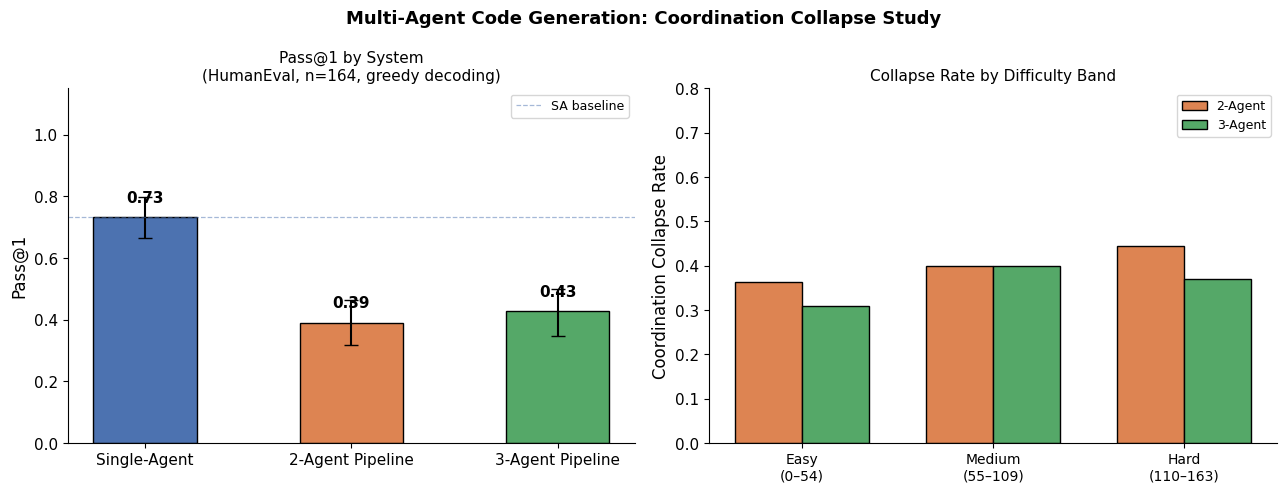

Saved: main_results.pdf / .png


In [22]:
# =========================================================
# CELL 19: Publication Plot — Pass@1 with 95% CI
# =========================================================

systems  = [r[0] for r in rows]
means    = [r[1] for r in rows]
ci_lo    = [r[2] for r in rows]
ci_hi    = [r[3] for r in rows]
yerr     = [[m - lo for m, lo in zip(means, ci_lo)],
            [hi - m for m, hi in zip(means, ci_hi)]]
colors   = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Pass@1 bar chart ───────────────────────────────
ax = axes[0]
bars = ax.bar(systems, means, color=colors, edgecolor="black", width=0.5,
              yerr=yerr, capsize=5, error_kw={"elinewidth":1.5})
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f"{val:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Pass@1", fontsize=12)
ax.set_title("Pass@1 by System\n(HumanEval, n=164, greedy decoding)", fontsize=11)
ax.axhline(means[0], color="#4C72B0", linestyle="--", lw=0.9, alpha=0.5, label="SA baseline")
ax.legend(fontsize=9)

# ── Right: Collapse rate by difficulty ───────────────────
ax2 = axes[1]
bands = ["Easy\n(0–54)", "Medium\n(55–109)", "Hard\n(110–163)"]
two_rates   = []
three_rates = []
for lo_b, hi_b in [(0,54),(55,109),(110,163)]:
    mask2 = df_2agent["task_id"].str.extract(r"(\d+)$")[0].astype(int).between(lo_b, hi_b)
    mask3 = df_3agent["task_id"].str.extract(r"(\d+)$")[0].astype(int).between(lo_b, hi_b)
    two_rates.append(df_2agent[mask2]["collapse"].mean())
    three_rates.append(df_3agent[mask3]["collapse"].mean())

x = np.arange(len(bands))
w = 0.35
ax2.bar(x - w/2, two_rates,   w, label="2-Agent", color="#DD8452", edgecolor="black")
ax2.bar(x + w/2, three_rates, w, label="3-Agent", color="#55A868", edgecolor="black")
ax2.set_xticks(x); ax2.set_xticklabels(bands, fontsize=10)
ax2.set_ylim(0, 0.8)
ax2.set_ylabel("Coordination Collapse Rate", fontsize=12)
ax2.set_title("Collapse Rate by Difficulty Band", fontsize=11)
ax2.legend(fontsize=9)

plt.suptitle("Multi-Agent Code Generation: Coordination Collapse Study", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("main_results.pdf", bbox_inches="tight")
plt.savefig("main_results.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: main_results.pdf / .png")

In [23]:
# =========================================================
# CELL 20: Save Full Per-Task Results Table
# =========================================================

df_full = df_sa[["task_id","passed"]].rename(columns={"passed":"sa_pass"}).copy()
df_full = df_full.merge(
    df_2agent[["task_id","pipe_pass","collapse","spec","code"]].rename(
        columns={"pipe_pass":"two_pass","collapse":"two_collapse","code":"two_code"}),
    on="task_id")
df_full = df_full.merge(
    df_3agent[["task_id","pipe_pass","collapse","validator_verdict","violations"]].rename(
        columns={"pipe_pass":"three_pass","collapse":"three_collapse"}),
    on="task_id")

df_full.to_csv("full_results_table.csv", index=False)
print(f"Full table saved: full_results_table.csv  ({len(df_full)} rows)")
print()
print(df_full[["task_id","sa_pass","two_pass","three_pass",
               "two_collapse","three_collapse","validator_verdict"]].to_string(index=False))

Full table saved: full_results_table.csv  (164 rows)

      task_id  sa_pass  two_pass  three_pass  two_collapse  three_collapse validator_verdict
  HumanEval/0     True     False       False          True            True         VIOLATION
  HumanEval/1    False     False       False         False           False         COMPLIANT
  HumanEval/2     True      True        True         False           False         COMPLIANT
  HumanEval/3     True     False       False          True            True         COMPLIANT
  HumanEval/4     True     False       False          True            True         COMPLIANT
  HumanEval/5     True     False        True          True           False         VIOLATION
  HumanEval/6     True     False       False          True            True         VIOLATION
  HumanEval/7     True     False        True          True           False         VIOLATION
  HumanEval/8    False     False       False         False           False         VIOLATION
  HumanEval/9   

In [24]:
import json

with open("/home/mluser/foldername/ablation/ablation1/trial_final_v4_6b.ipynb") as f:
    nb = json.load(f)

with open("all_outputs.txt", "w") as out:
    for i, cell in enumerate(nb["cells"]):
        if cell.get("outputs"):
            out.write(f"=== Cell {i+1} ===\n")
            for o in cell["outputs"]:
                if "text" in o:
                    out.write("".join(o["text"]))
                elif "data" in o and "text/plain" in o["data"]:
                    out.write("".join(o["data"]["text/plain"]))
                if o.get("ename"):
                    out.write(f"{o['ename']}: {o['evalue']}\n")
                out.write("\n")

print("All outputs saved to all_outputs.txt")

All outputs saved to all_outputs.txt
